<a href="https://colab.research.google.com/github/shanikagalaudage/includeher_paper/blob/main/PlotsTables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Notes

All figures and unique-scientist counts come from `Plot_Figures_UK.py`, so running this notebook produces the same outputs as `python Plot_Figures_UK.py`.

Unique counts treat the same person as one within each key stage, then once across both stages if the `Name of Scientist` string matches. Blank / `nan` name rows are excluded.

In [1]:
%matplotlib inline
import os
import sys
sys.path.insert(0, os.path.abspath("."))
import Plot_Figures_UK as pf

colours = pf.COLOURS

# Key Stage 5 — A-Level / Scottish Highers


In [2]:
ks5 = pf.prepare_key_stage("ks5")



=== UNIQUE SCIENTISTS (GLOBAL, DEDUPLICATED ACROSS ALL EXAM BOARDS) ===
Total unique scientists (distinct named individuals): 181
  178 male, 3 female
  Women named: inge lehmann, marie tharp, rosalind franklin
Unique scientists by gender: {'male': 178, 'female': 3}
Unique scientists by region: {'europe': 136, 'north america': 36, 'oceania': 1, 'europe-north america': 4, 'asia-north america': 1, 'oceania-europe': 1}

=== TOTAL SCIENTIST-CATEGORY MENTIONS PER EXAM BOARD ===
AQA: 0 scientist-category mentions
CCEA: 0 scientist-category mentions
Edexcel: 0 scientist-category mentions
OCR: 16 scientist-category mentions
Scottish_highers: 10 scientist-category mentions
WJEC: 4 scientist-category mentions

=== TOTAL CONCEPT-CATEGORY MENTIONS PER EXAM BOARD ===
AQA: 101 concept-category mentions
CCEA: 55 concept-category mentions
Edexcel: 57 concept-category mentions
OCR: 85 concept-category mentions
Scottish_highers: 87 concept-category mentions
WJEC: 83 concept-category mentions

=== TOTAL

### Optional: search specification PDFs for scientist names

This cell looks for names in the PDFs in `Specs/` (currently the three BTEC Applied Science specifications).

- **Counted names** come from the KS4/KS5 CSVs and are left unchanged.
- **Extra names** are additional surnames you want to check. They are searched separately and are **not** added to the counted list. Any extra name that is already in the counted list is skipped automatically.

Set `RUN_PDF_SEARCH = False` to skip this when running the whole notebook.


In [3]:
# Set to False to skip this cell when running the whole notebook
RUN_PDF_SEARCH = False

# Additional names to look for in PDFs. Do not add these to the counted scientist list.
EXTRA_NAMES = list(pf.DEFAULT_EXTRA_SEARCH_NAMES)

# All PDFs currently in Specs/ (optional local folder; not required for paper stats)
pdf_files = pf.list_spec_pdfs()
print("PDFs to search:")
for path in pdf_files:
    print(f"  {path}")

if RUN_PDF_SEARCH:
    if not pdf_files:
        print(f"No PDFs found in {pf.SPECS_DIR}")
    else:
        counted_names = pf.counted_scientist_names()
        print(f"\nCounted names from KS4/KS5 CSVs: {len(counted_names)}")
        print(f"Extra names to search: {len(EXTRA_NAMES)}")
        pf.report_pdf_search(
            pf.search_names_in_pdfs(
                pdf_files,
                counted_names=counted_names,
                extra_names=EXTRA_NAMES,
            )
        )
else:
    print("PDF search skipped (RUN_PDF_SEARCH = False)")

PDFs to search:
PDF search skipped (RUN_PDF_SEARCH = False)


### KS5 figures (same functions as `Plot_Figures_UK.py`)

Saved: /Users/gregcooke/IncludeHerUK/Figures/summary_subjects_A_Level_UK.png


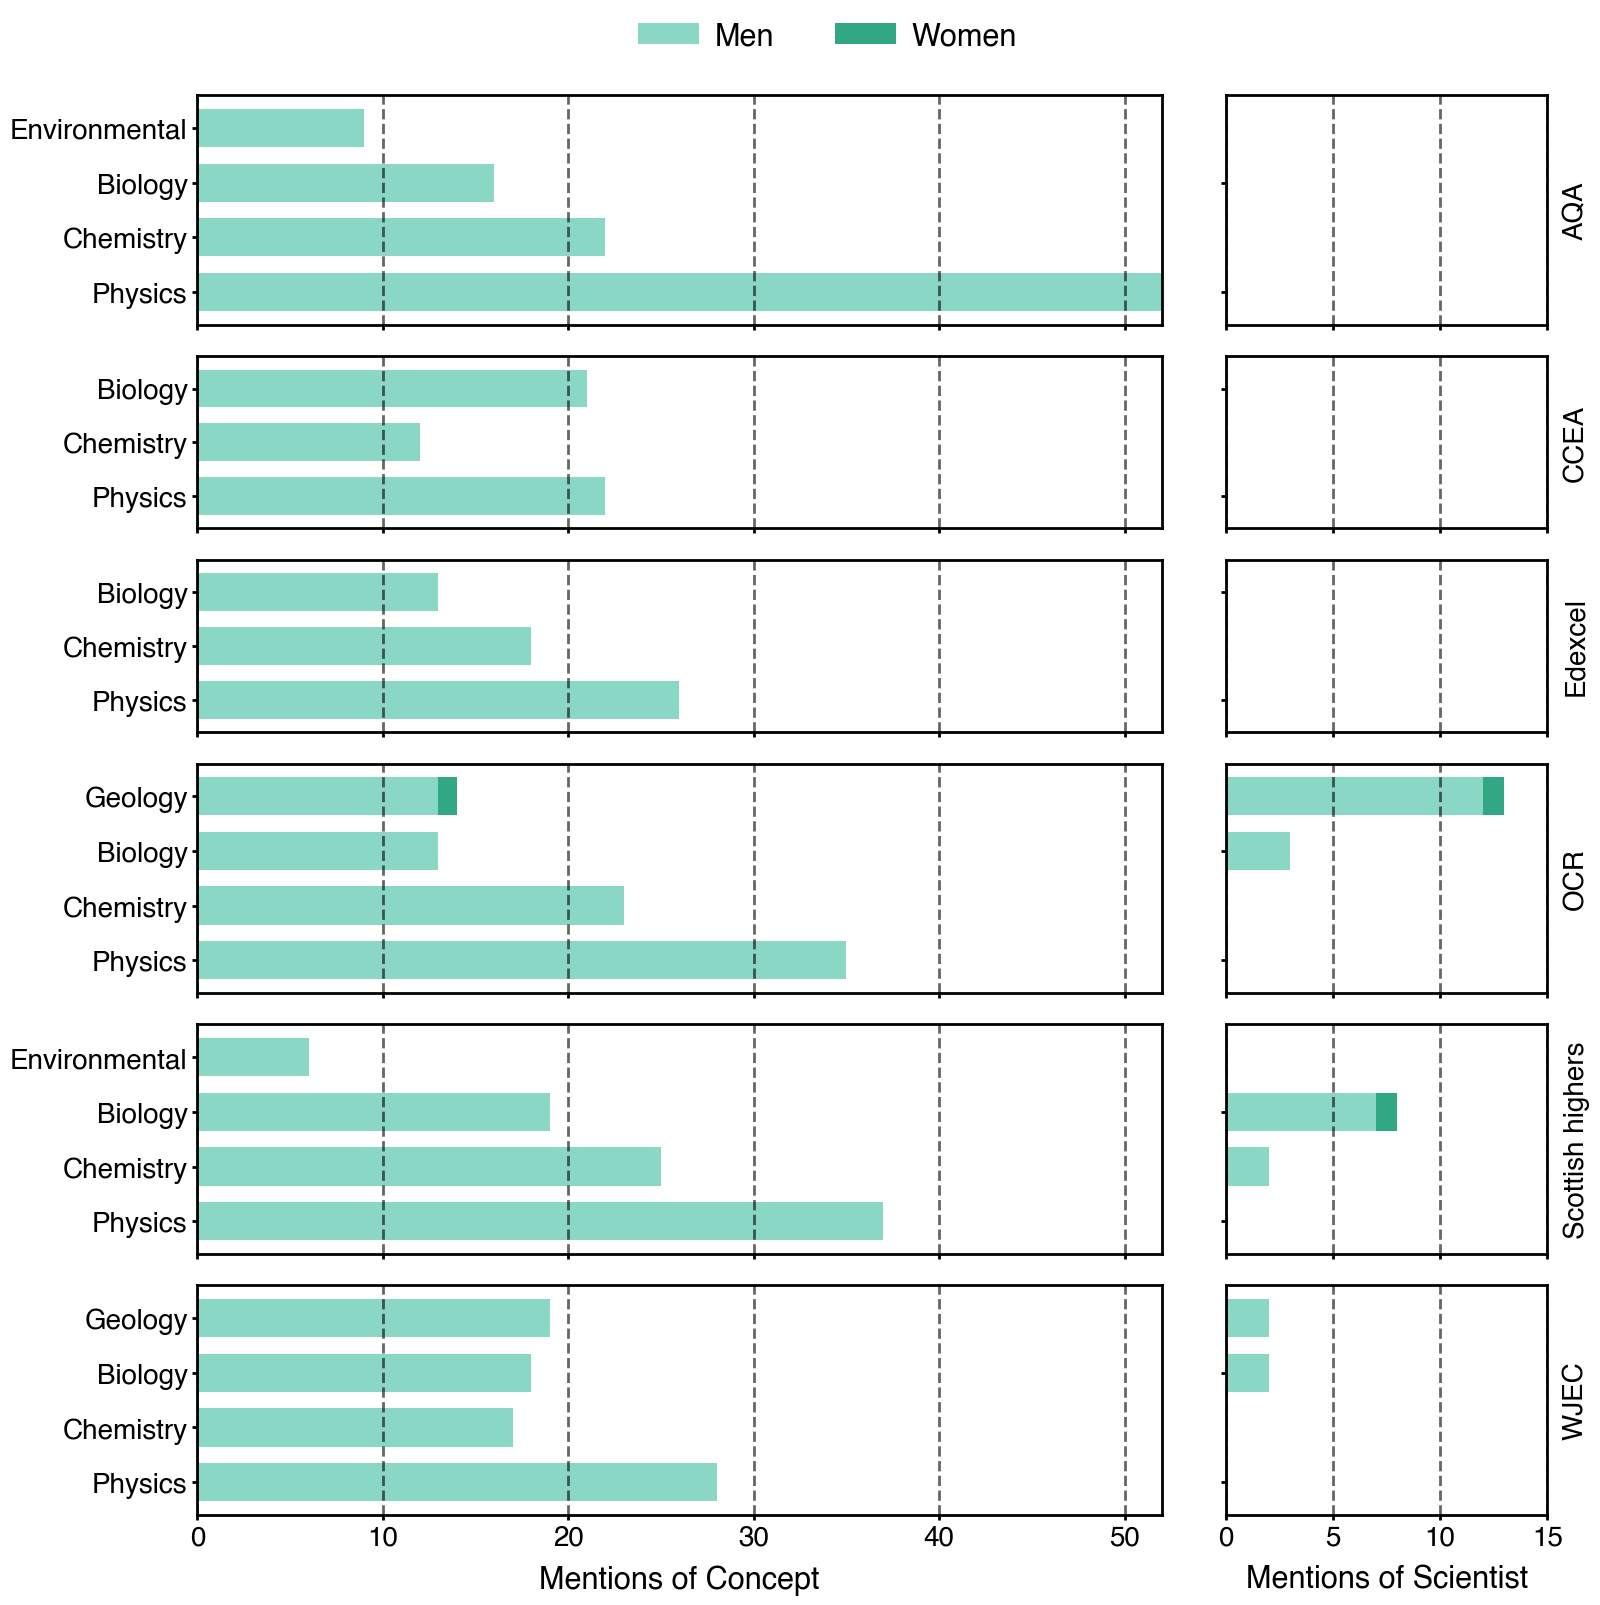

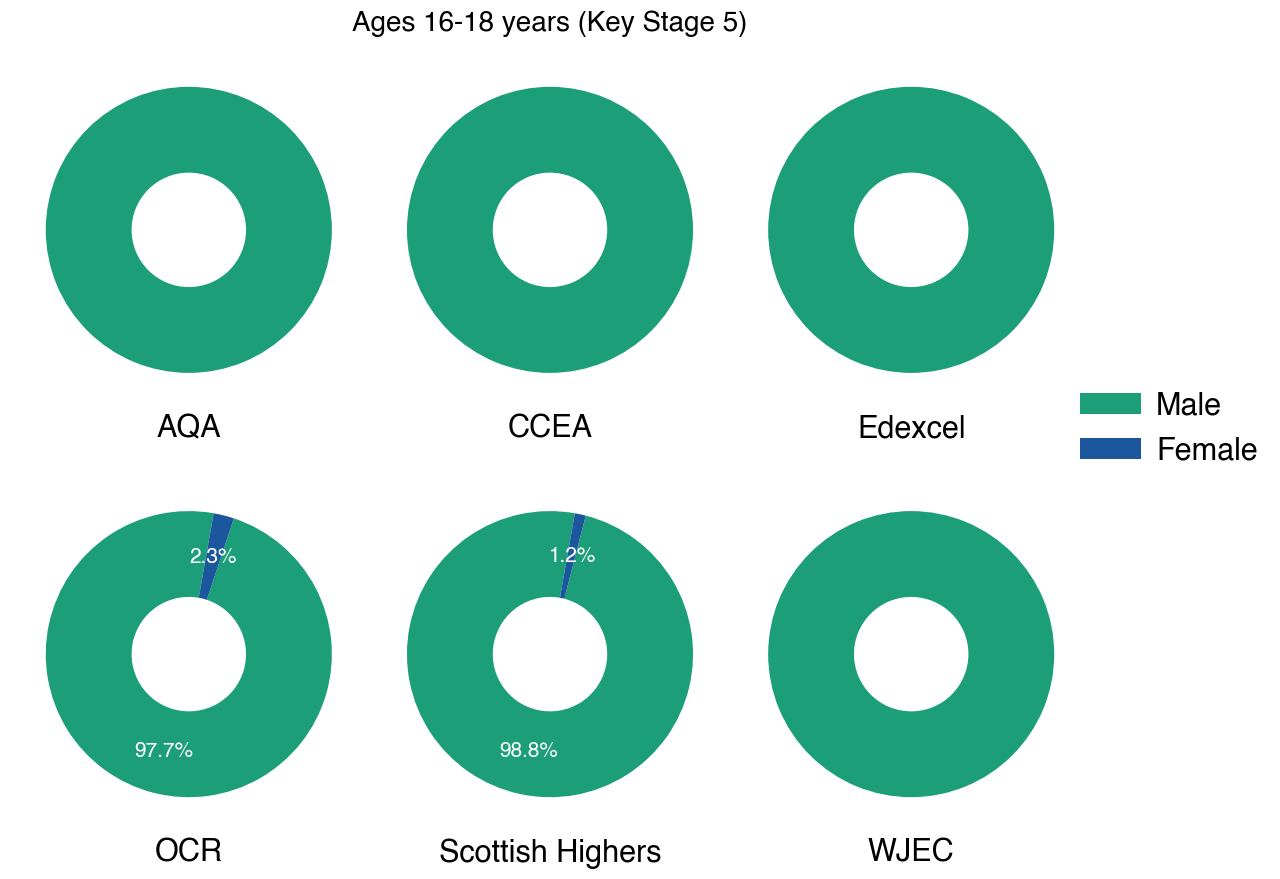

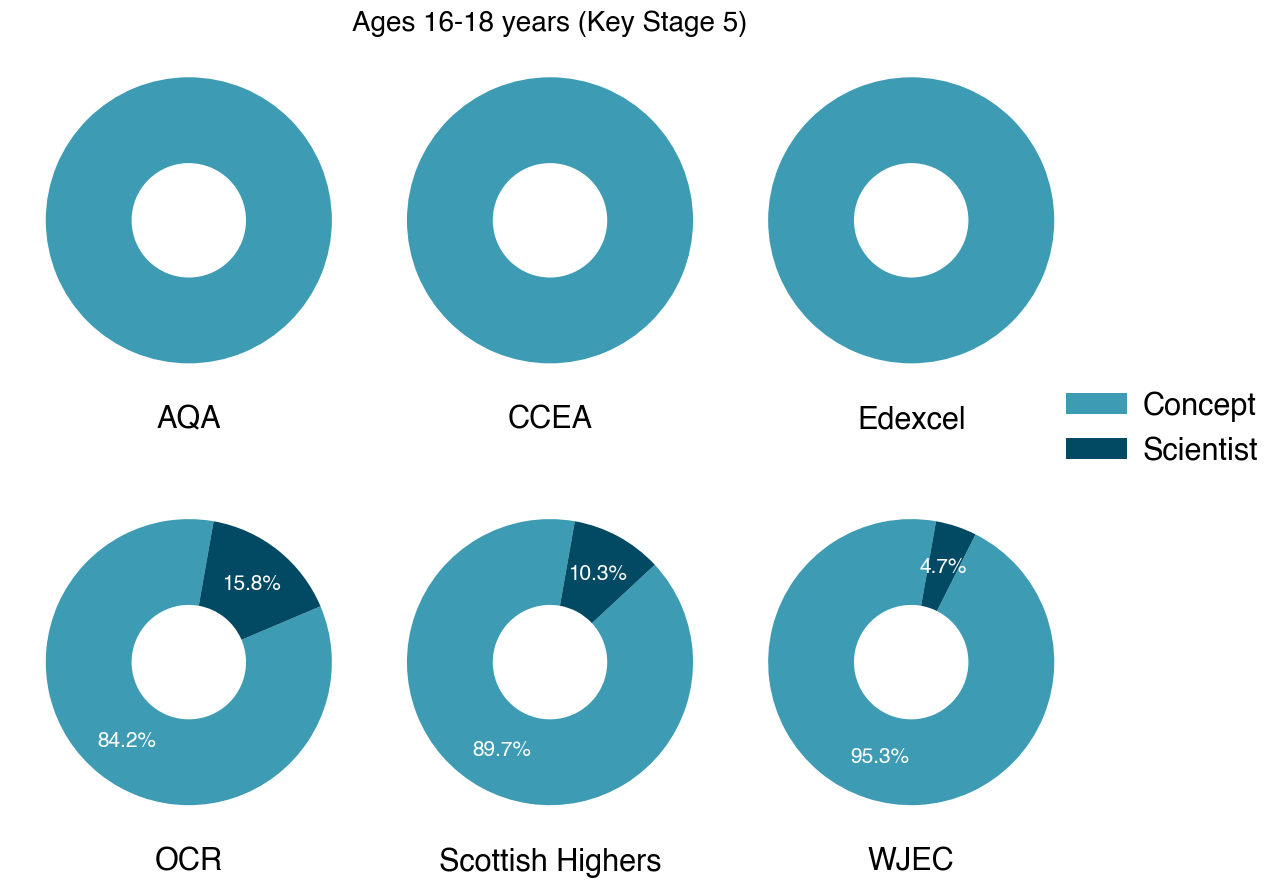

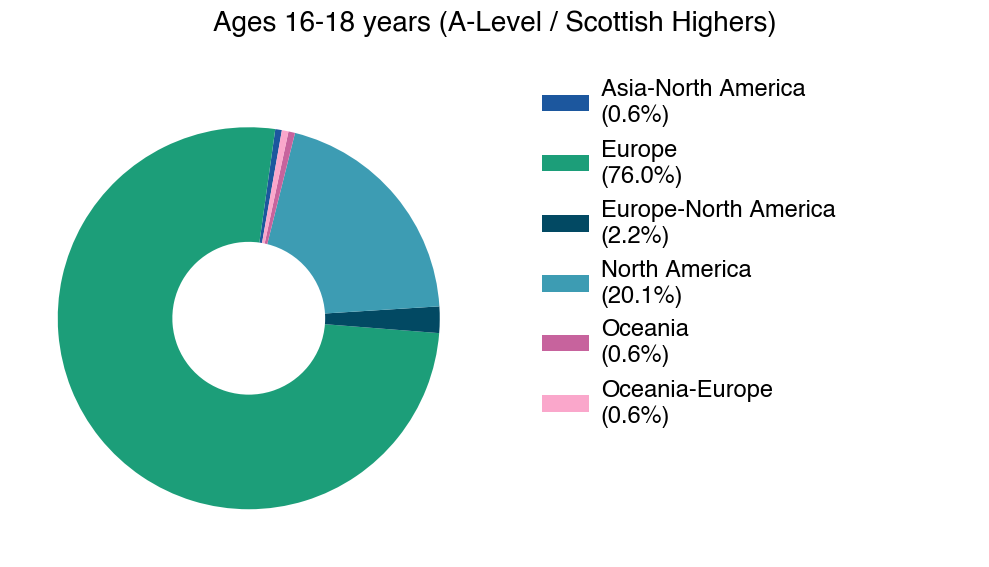

In [4]:
pf.plot_key_stage_figures(ks5, colours)

Gender pies, mention-type pies, and the region donut for KS5 are written by `plot_key_stage_figures` in the previous cell.

In [5]:
# KS5 pies and region donut are created by pf.plot_key_stage_figures above.

# Key Stage 4 — GCSE / NQ5


In [6]:
ks4 = pf.prepare_key_stage("ks4")



=== UNIQUE SCIENTISTS (GLOBAL, DEDUPLICATED ACROSS ALL EXAM BOARDS) ===
Total unique scientists (distinct named individuals): 86
  85 male, 1 female
  Women named: rosalind franklin
Unique scientists by gender: {'male': 85, 'female': 1}
Unique scientists by region: {'europe': 63, 'north america': 13, 'oceania': 2, 'africa': 2, 'asia-north america': 1, 'europe-oceania': 1, 'oceania-europe': 1}

=== TOTAL SCIENTIST-CATEGORY MENTIONS PER EXAM BOARD ===
AQA: 12 scientist-category mentions
CCEA: 5 scientist-category mentions
Edexcel: 20 scientist-category mentions
OCR_A: 11 scientist-category mentions
OCR_B: 23 scientist-category mentions
Scottish: 1 scientist-category mentions
WJEC: 16 scientist-category mentions

=== TOTAL CONCEPT-CATEGORY MENTIONS PER EXAM BOARD ===
AQA: 18 concept-category mentions
CCEA: 25 concept-category mentions
Edexcel: 43 concept-category mentions
OCR_A: 23 concept-category mentions
OCR_B: 12 concept-category mentions
Scottish: 13 concept-category mentions
WJEC: 

### KS4 figures (same functions as `Plot_Figures_UK.py`)

Saved: /Users/gregcooke/IncludeHerUK/Figures/summary_subjects_GCSE_UK.png


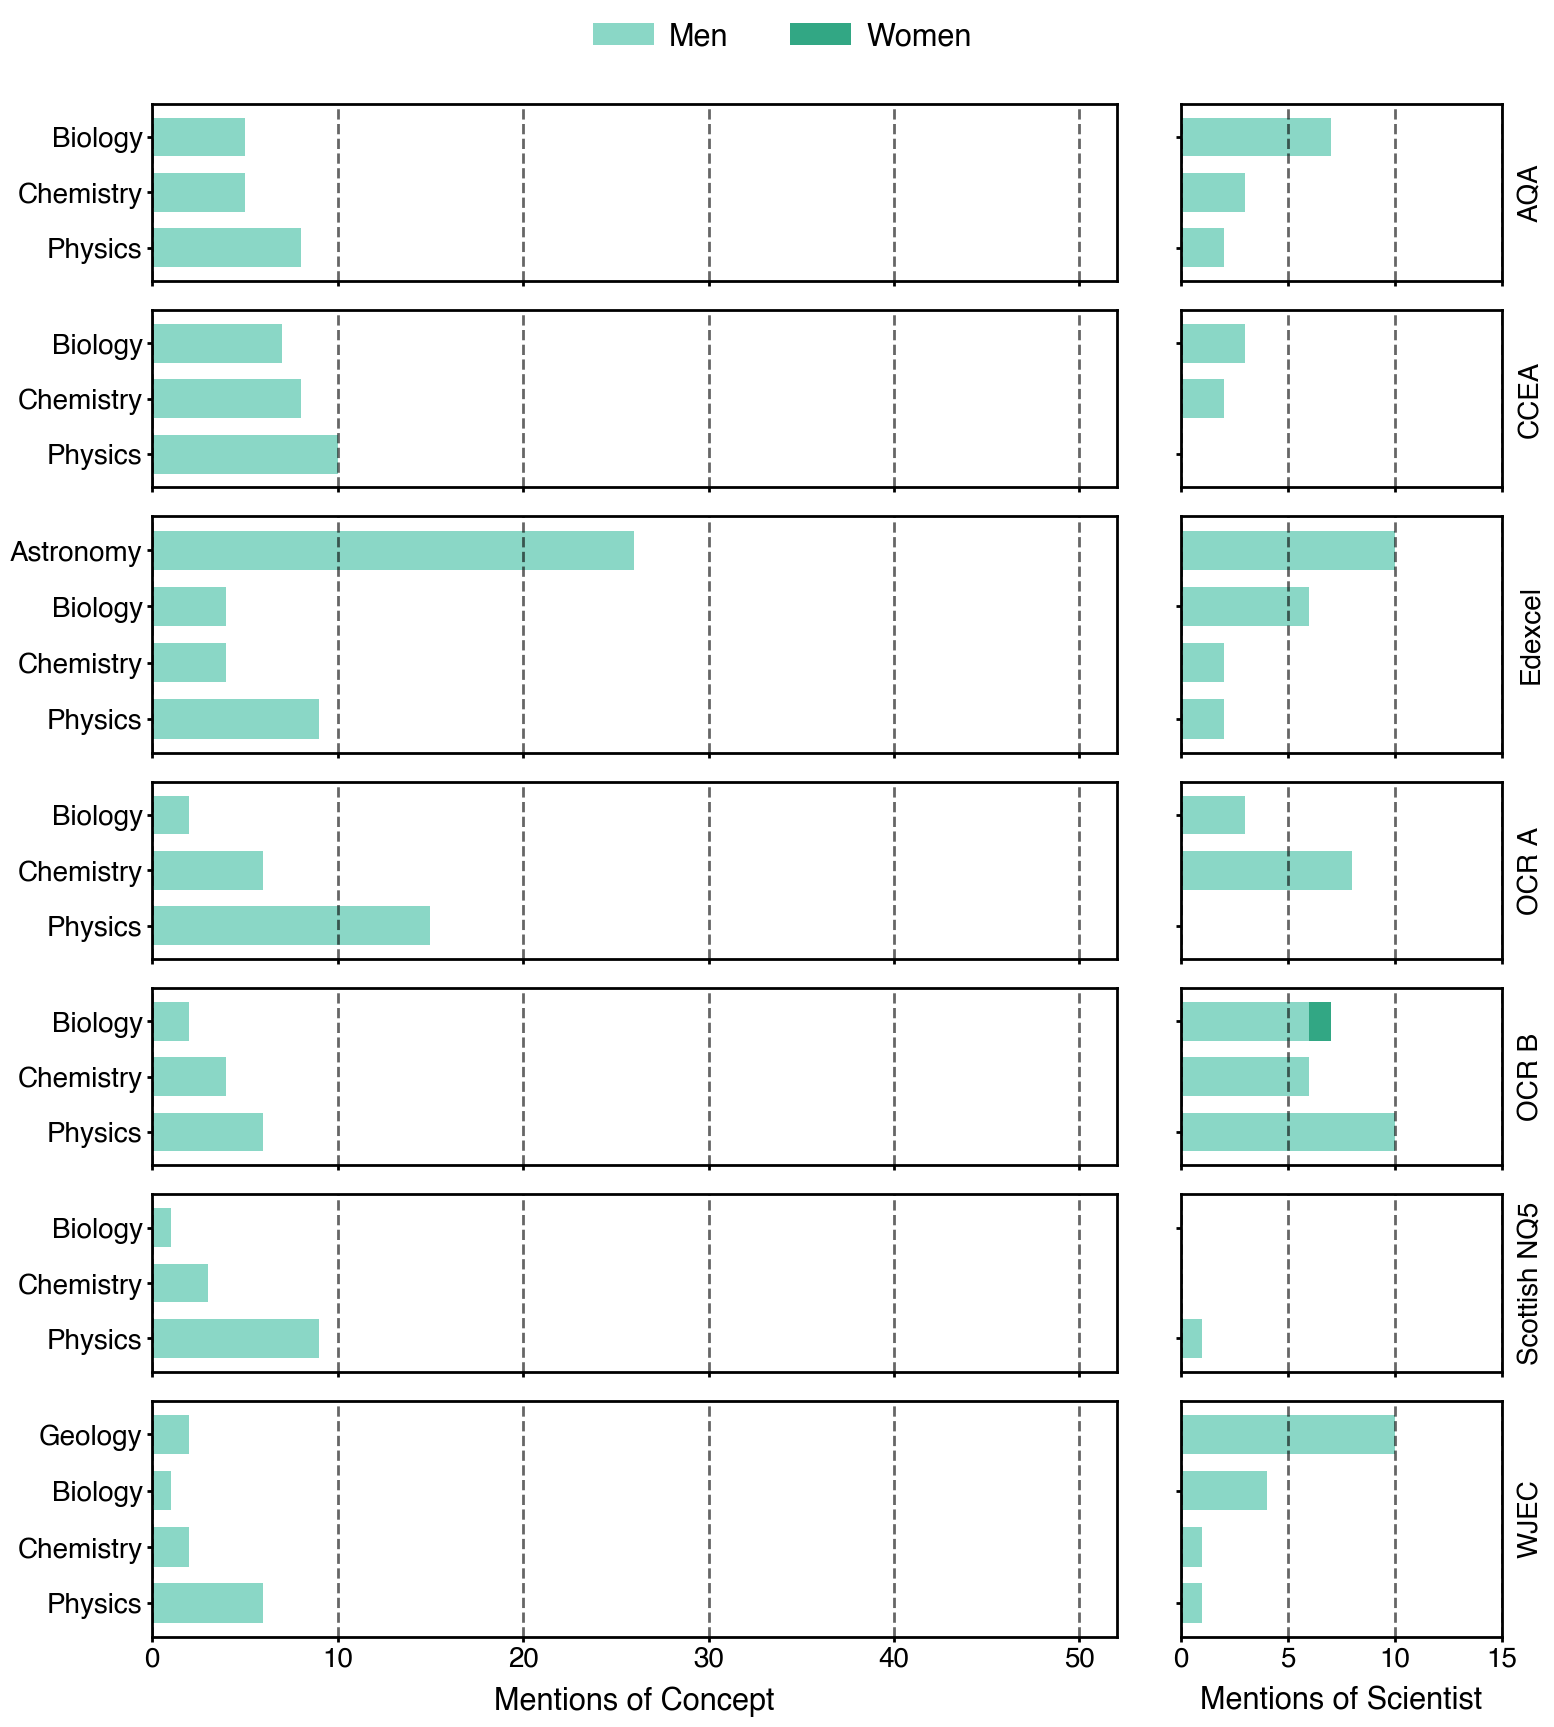

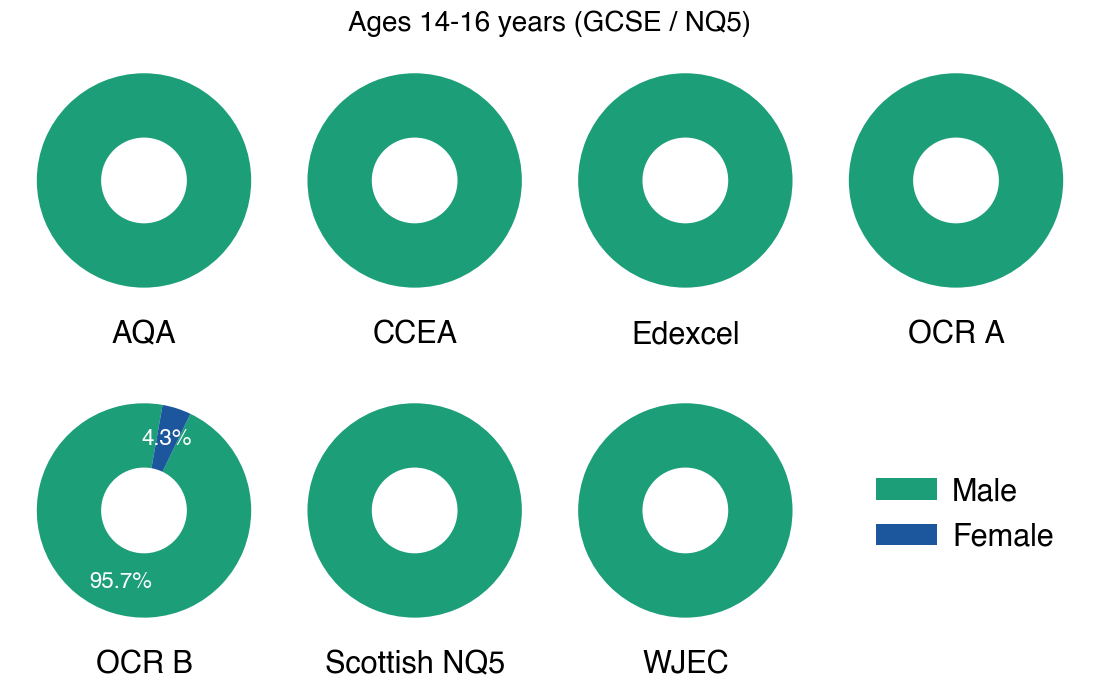

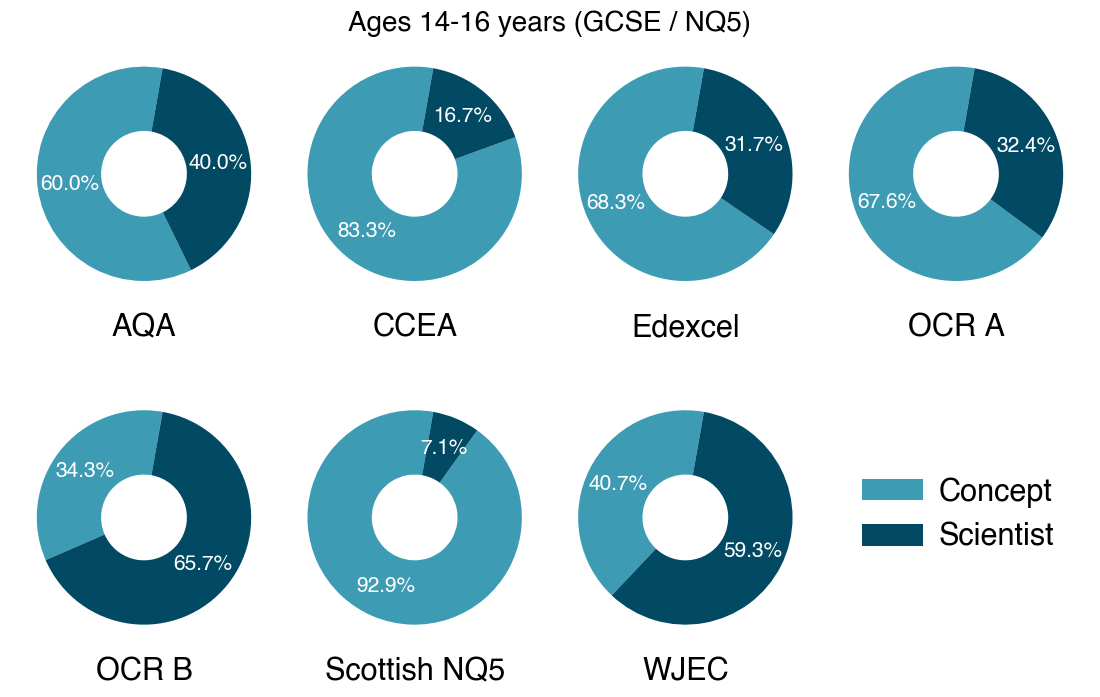

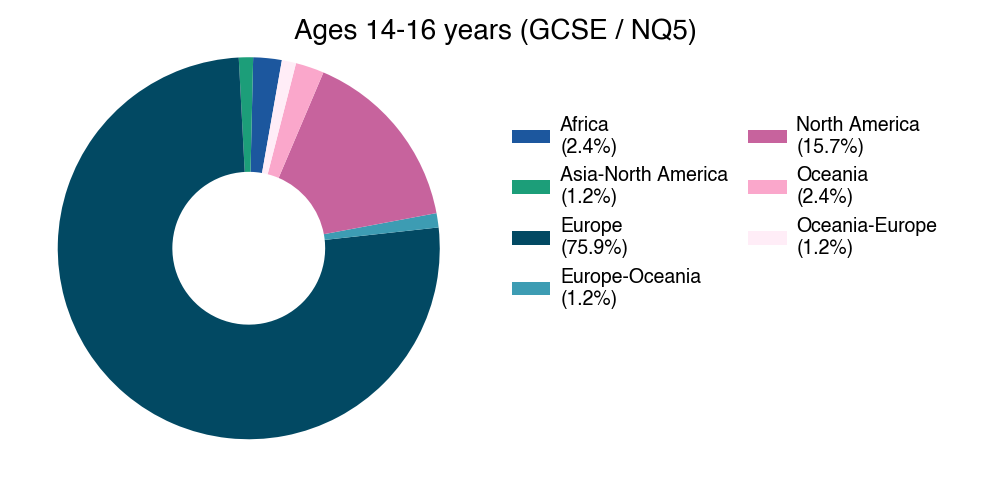

In [7]:
pf.plot_key_stage_figures(ks4, colours)

Gender pies, mention-type pies, and the region donut for KS4 are written by `plot_key_stage_figures` in the previous cell.

In [8]:
# KS4 pies and region donut are created by pf.plot_key_stage_figures above.

# Combined figures


Saved: /Users/gregcooke/IncludeHerUK/Figures/summary_overall_gender_UK.png


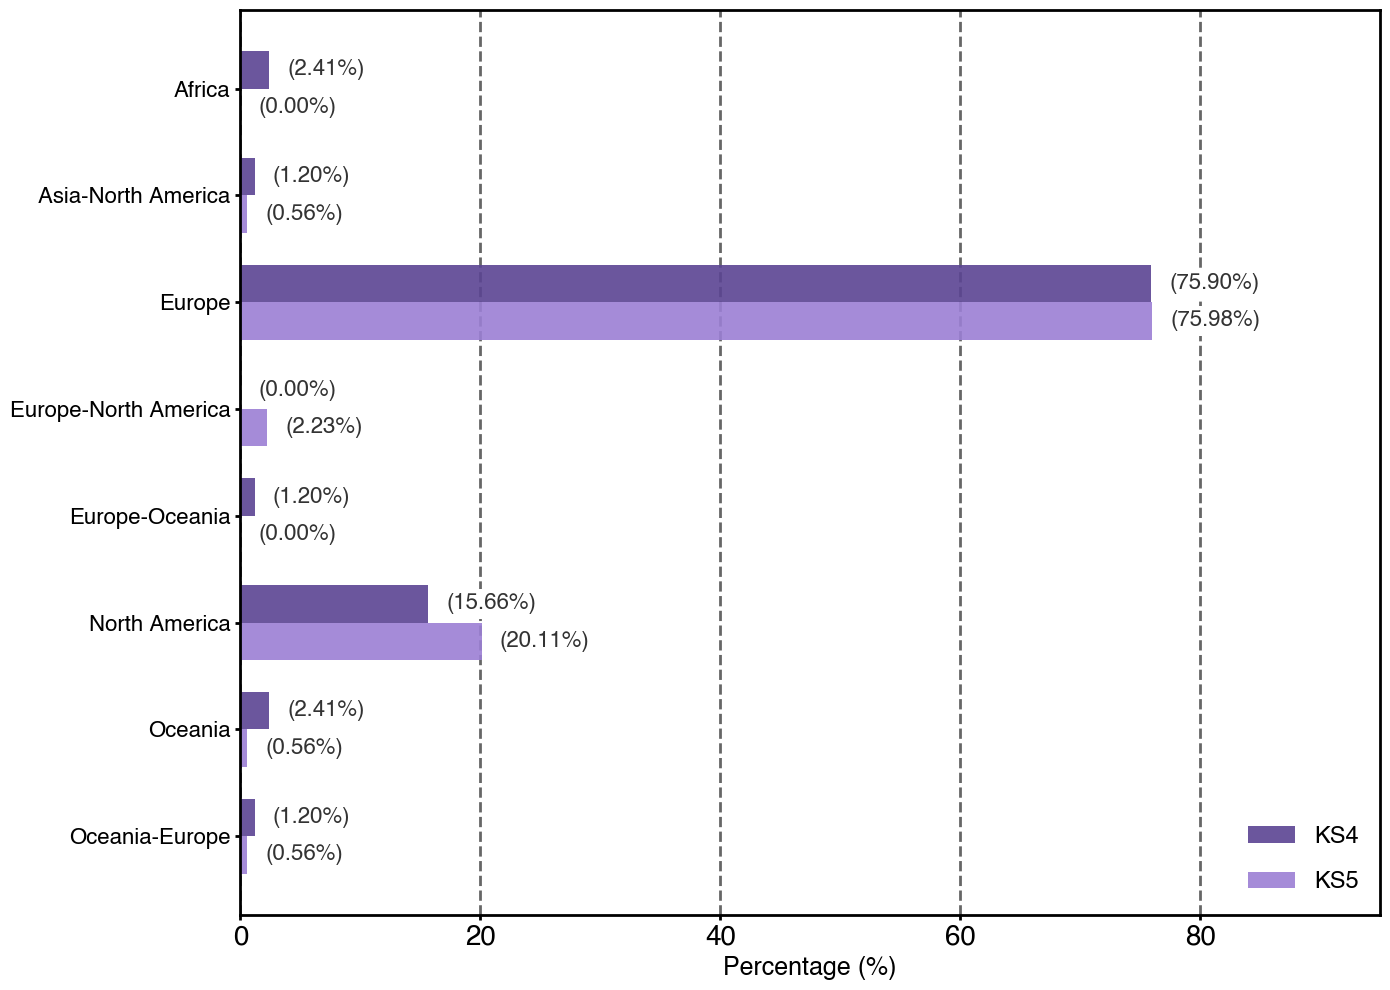

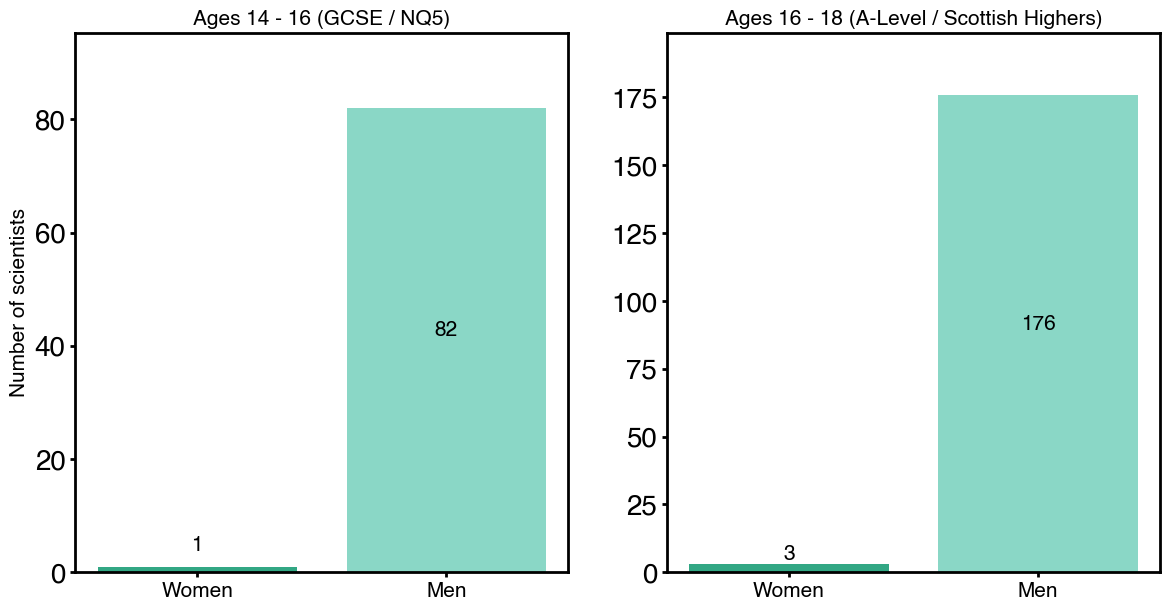

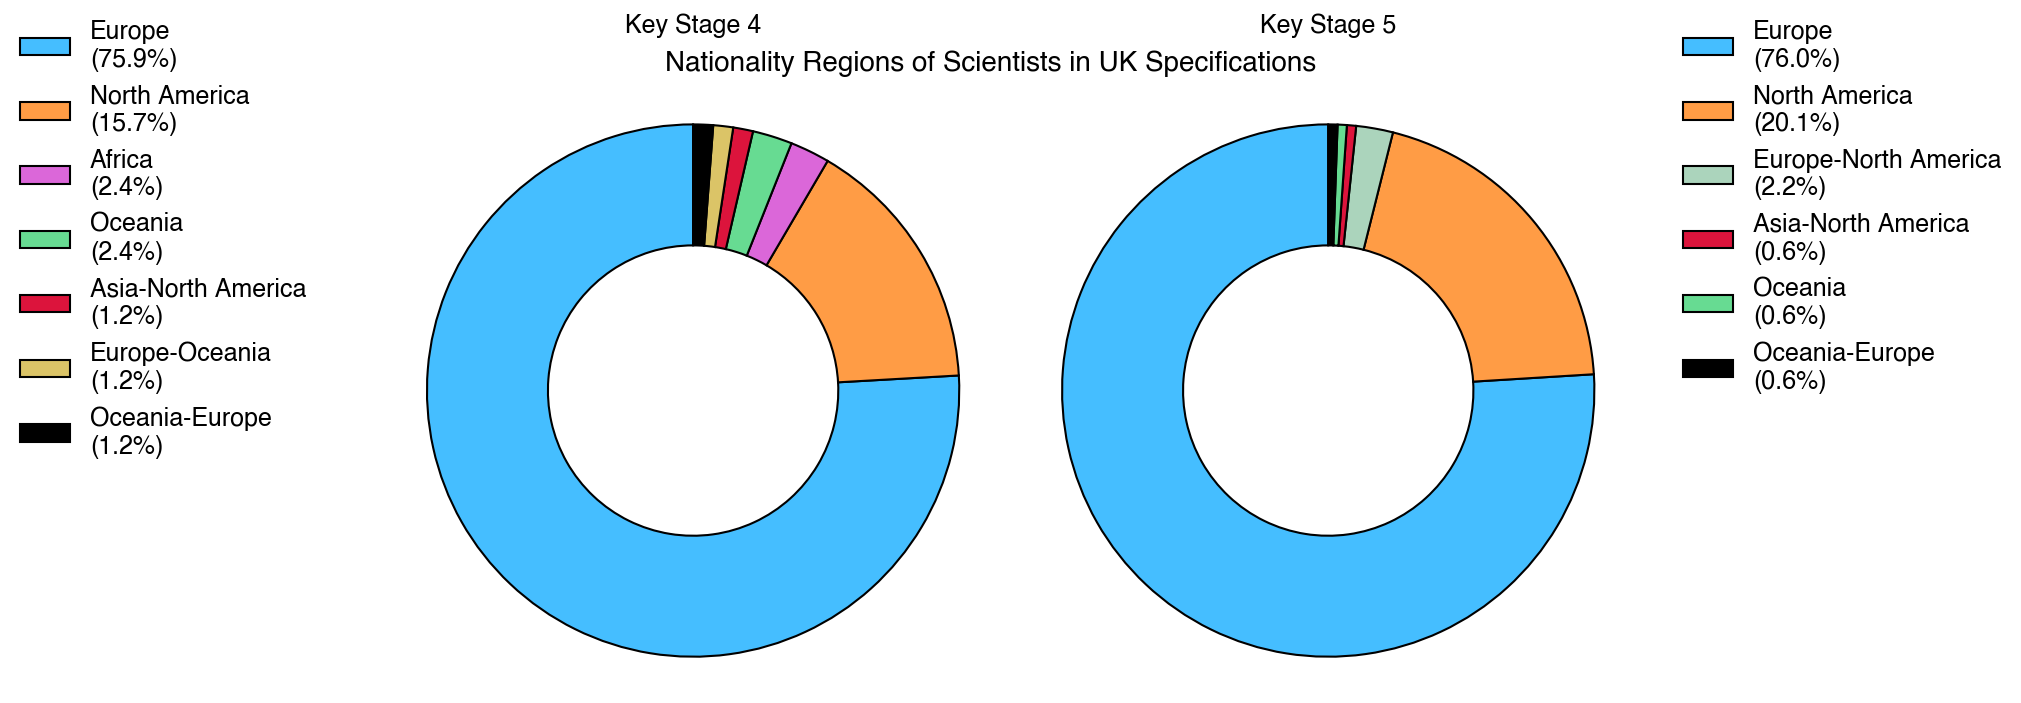

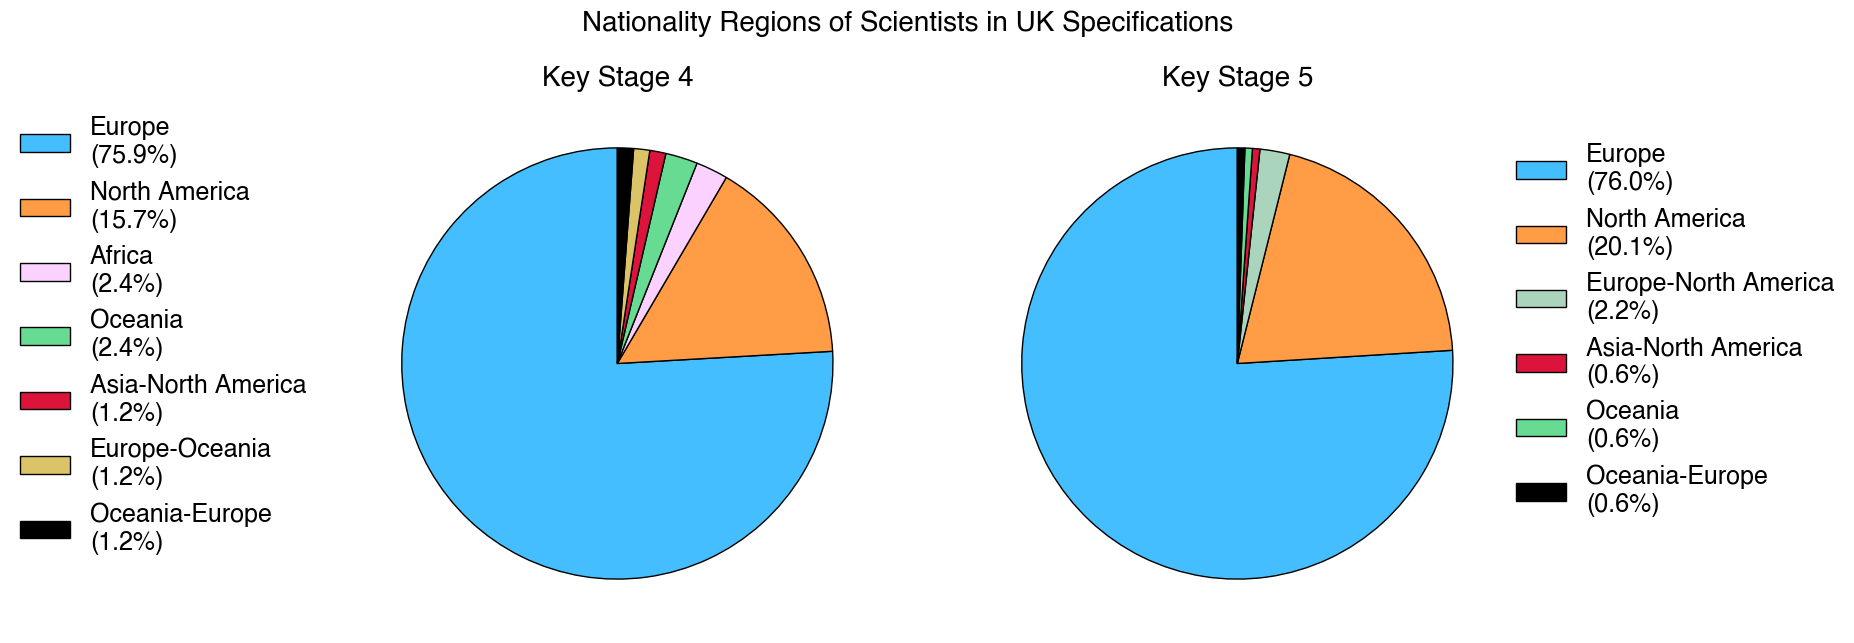

In [9]:
pf.plot_combined_figures(ks4, ks5)

# Distinct individual scientist names

Run the cell below after the KS5 and KS4 data cells. Unique counts treat the same person as one within each key stage, then once across both stages if the name string matches. This is the table used in the paper (male / female / total).


In [10]:
combined = pf.print_all_distinct_scientists(ks5["scientists"], ks4["scientists"])
pf.print_distinct_scientist_names(ks5["scientists"], "A-Level / KS5")
pf.print_distinct_scientist_names(ks4["scientists"], "GCSE / KS4")
pf.print_distinct_scientist_names(combined, "KS4 + KS5 combined")


=== Unique scientist counts ===
Each person is counted once per key stage, then once across both stages if the Name of Scientist string matches.
A-Level / KS5: 181 unique scientists (178 male, 3 female)
GCSE / KS4: 86 unique scientists (85 male, 1 female)
KS4 + KS5 combined (each person counted once): 226 unique scientists (223 male, 3 female)
KS5 women: inge lehmann, marie tharp, rosalind franklin
KS4 women: rosalind franklin
Combined women: inge lehmann, marie tharp, rosalind franklin

=== A-Level / KS5 — distinct individual names ===
Total unique scientists: 179

adolf fick
albert a. michelson
albert einstein
albert tullgren
alexander william williamson
alfred russel wallace
amedeo avogadro
andrew miall
andrija mohorovi?i?
archimedes of syracuse
arthur holly compton
ben goldacre
beno gutenberg
bernard sachs
bernhard tollens
bryan sykes
camillo golgi
charles darwin
charles friedel
charles lyell
charles spearman
charles vernon boys
charles-augustin de coulomb
christiaan huygens
chris